<a href="https://colab.research.google.com/github/vikash-mahar/AI-MLNotes/blob/main/31BatchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving random.csv to random.csv


In [3]:
df = pd.read_csv('random.csv')

In [4]:
df.head()

,feature1,feature2,label
0,0.374540,0.969585,0
1,0.950714,0.775133,1
2,0.731994,0.939499,0
3,0.598658,0.894827,0
4,0.156019,0.597900,1


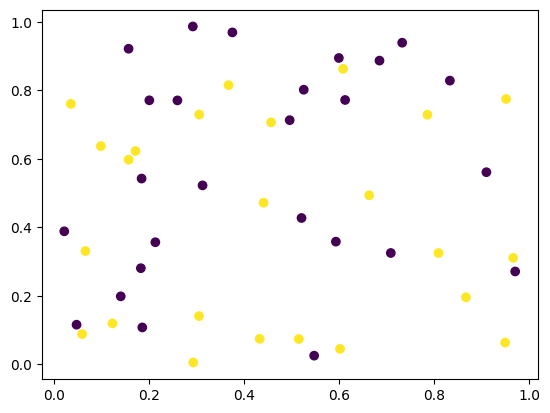

In [5]:
plt.scatter(df['feature1'],df['feature2'],c=df['label'])

In [6]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [7]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [8]:
model = Sequential()

model.add(Dense(2,activation='relu',input_dim=2))
model.add(Dense(2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
history1 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 261ms/step - accuracy: 0.6083 - loss: 0.6881 - val_accuracy: 0.3000 - val_loss: 0.6993
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5167 - loss: 0.6883 - val_accuracy: 0.3000 - val_loss: 0.6999
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5167 - loss: 0.6877 - val_accuracy: 0.3000 - val_loss: 0.7006
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5375 - loss: 0.6882 - val_accuracy: 0.3000 - val_loss: 0.7011
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5167 - loss: 0.6876 - val_accuracy: 0.3000 - val_loss: 0.7015
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5375 - loss: 0.6874 - val_accuracy: 0.3000 - val_loss: 0.7019
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5167 - loss: 0.6874 - val_accuracy: 0.3000 - val_loss: 0.7022
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5167 - loss: 0.6872 - val_accuracy: 0.3000 - val_loss

In [11]:
model = Sequential()

model.add(Dense(3,activation='relu',input_dim=2))
model.add(BatchNormalization())
model.add(Dense(2,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3)              │            12 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2)              │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history2 = model.fit(X,y,epochs=200,validation_split=0.2)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 286ms/step - accuracy: 0.3583 - loss: 1.3535 - val_accuracy: 0.3000 - val_loss: 1.0088
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3646 - loss: 1.3444 - val_accuracy: 0.3000 - val_loss: 1.0031
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4188 - loss: 1.3326 - val_accuracy: 0.3000 - val_loss: 0.9975
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4354 - loss: 1.3578 - val_accuracy: 0.3000 - val_loss: 0.9921
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4521 - loss: 1.3296 - val_accuracy: 0.3000 - val_loss: 0.9871
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4562 - loss: 1.3036 - val_accuracy: 0.3000 - val_loss: 0.9821
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3854 - loss: 1.2898 - val_accuracy: 0.3000 - val_loss: 0.9763
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3583 - loss: 1.2958 - val_accuracy: 0.3000 - val_loss

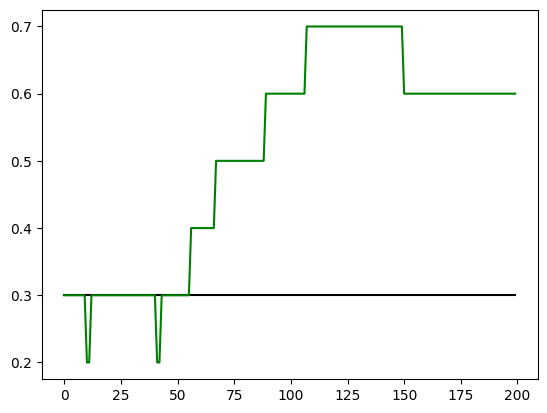

In [14]:
plt.plot(history1.history['val_accuracy'],color='black')
plt.plot(history2.history['val_accuracy'],color='green')